<a href="https://colab.research.google.com/github/jahnavitelsang/DATASCIENCE/blob/main/Datatransformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/content/Diab.csv')

In [3]:
df.head()

,Pat_Id,Gender,OGTT,DBP,BMI,Age,Diabetic
0,101,Male,176,90,33.7,58,Yes
1,102,Male,150,66,34.7,42,No
2,103,Male,73,50,23.0,21,No
3,104,Female,187,68,37.7,41,Yes
4,105,Female,100,88,46.8,31,No


In [ ]:
#lets separate the numerical and categorical part

In [4]:
data_cat = df[['Gender','Diabetic']]
data_cat.head()

,Gender,Diabetic
0,Male,Yes
1,Male,No
2,Male,No
3,Female,Yes
4,Female,No


In [5]:
data_num = df.iloc[:,2:6]
data_num.head()

,OGTT,DBP,BMI,Age
0,176,90,33.7,58
1,150,66,34.7,42
2,73,50,23.0,21
3,187,68,37.7,41
4,100,88,46.8,31


In [6]:
#standardization
from sklearn.preprocessing import StandardScaler

In [10]:
ss = StandardScaler()
#fit means to get the mean and sd of that set and applies the stand formula
ss_x = ss.fit_transform(data_num)
ss_x = pd.DataFrame(ss_x)
ss_x.columns = ['OGTT',	'DBP',	'BMI',	'Age']
ss_x.head()

,OGTT,DBP,BMI,Age
0,1.806312,1.512904,0.191222,2.133749
1,0.957604,-0.537564,0.334117,0.769678
2,-1.555878,-1.904543,-1.337752,-1.020667
3,2.165380,-0.366692,0.762801,0.684423
4,-0.674527,1.342031,2.063143,-0.168122


In [ ]:
#scaling/normalization

In [11]:
from sklearn.preprocessing import MinMaxScaler
MS = MinMaxScaler()
MS_x = MS.fit_transform(data_num)
MS_x = pd.DataFrame(MS_x)
MS_x.columns = ['OGTT',	'DBP',	'BMI',	'Age']
MS_x.head()

,OGTT,DBP,BMI,Age
0,0.857143,0.652174,0.316973,0.616667
1,0.688312,0.391304,0.337423,0.350000
2,0.188312,0.217391,0.098160,0.000000
3,0.928571,0.413043,0.398773,0.333333
4,0.363636,0.630435,0.584867,0.166667


In [ ]:
#encoding 1)label encoding

In [17]:
from sklearn.preprocessing import LabelEncoder
LE = LabelEncoder()
data_cat['Gender_LE'] = LE.fit_transform(df['Gender'])
data_cat['Diabetic_LE'] = LE.fit_transform(df['Diabetic'])
data_cat.head()

/tmp/ipykernel_1039/3925651440.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cat['Gender_LE'] = LE.fit_transform(df['Gender'])
/tmp/ipykernel_1039/3925651440.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cat['Diabetic_LE'] = LE.fit_transform(df['Diabetic'])


,Gender,Diabetic,Gender_LE,Diabetic_LE
0,Male,Yes,1,1
1,Male,No,1,0
2,Male,No,1,0
3,Female,Yes,0,1
4,Female,No,0,0


In [23]:
#one hot encoding
from sklearn.preprocessing import OneHotEncoder
ONE = OneHotEncoder()

In [27]:
#data_cat[['Gender']]extracts the 'Gender' column from your categorical DataFrame#
#fit: The encoder looks at the column and learns all the unique categories (in this case, it finds two: Female and Male)#
#transform: It maps those categories to a sparse matrix of binary vectors (0s and 1s)#

df_g = pd.DataFrame(ONE.fit_transform(data_cat[['Gender']]).toarray())
df_g.columns = ['Female', 'Male']
df_g.head()

,Female,Male
0,0.0,1.0
1,0.0,1.0
2,0.0,1.0
3,1.0,0.0
4,1.0,0.0


In [ ]:
#Data Partition#

In [2]:
import pandas as pd
df = pd.read_csv('/content/advertising.csv')

In [6]:
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,27-03-2016 00:53,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,04-04-2016 01:39,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,13-03-2016 20:35,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,10-01-2016 02:31,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,03-06-2016 03:36,0


In [2]:
df.shape

(1000, 10)

In [3]:
df.describe()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,65.000200,36.009000,55000.000080,180.000100,0.481000,0.50000
std,15.853615,8.785562,13414.634022,43.902339,0.499889,0.50025
min,32.600000,19.000000,13996.500000,104.780000,0.000000,0.00000
25%,51.360000,29.000000,47031.802500,138.830000,0.000000,0.00000
50%,68.215000,35.000000,57012.300000,183.130000,0.000000,0.50000
75%,78.547500,42.000000,65470.635000,218.792500,1.000000,1.00000
max,91.430000,61.000000,79484.800000,269.960000,1.000000,1.00000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


In [6]:
X = df[['Daily Time Spent on Site','Age','Area Income','Daily Internet Usage','Male']]
y = df['Clicked on Ad']

In [7]:
#Now train and test after the selecting the features and target#
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(700, 5)
(300, 5)
(700,)
(300,)


In [ ]:
#import any model

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [13]:
#initialize the model #
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [14]:
#simple predictions on y#
y_train_pred = log_model.predict(X_train)
y_test_pred = log_model.predict(X_test)

In [16]:
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
train_accuracy, test_accuracy

(0.9028571428571428, 0.8966666666666666)

In [17]:
train_classification_report = classification_report(y_train, y_train_pred)
test_classification_report = classification_report(y_test, y_test_pred)
print(train_classification_report)
print(test_classification_report)

              precision    recall  f1-score   support

           0       0.88      0.93      0.91       354
           1       0.92      0.88      0.90       346

    accuracy                           0.90       700
   macro avg       0.90      0.90      0.90       700
weighted avg       0.90      0.90      0.90       700

              precision    recall  f1-score   support

           0       0.85      0.96      0.90       146
           1       0.96      0.84      0.89       154

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300



In [18]:
train_cunfusion_matrix = confusion_matrix(y_train, y_train_pred)
test_confusion_matrix = confusion_matrix(y_test, y_test_pred)
print(train_cunfusion_matrix)
print(test_confusion_matrix)


[[329  25]
 [ 43 303]]
[[140   6]
 [ 25 129]]


In [ ]:
#Now apply shuffleslpit

In [20]:
#ShuffleSplit: A validation strategy that randomly samples a percentage of data for training and testing over multiple iterations.
#cross_validate: The execution engine,repeatedly splitting the data, training the model, and capturing the evaluation scores for every single iteration.
from sklearn.model_selection import ShuffleSplit, cross_val_score, cross_validate

In [25]:
model = LogisticRegression(solver = 'liblinear')

In [33]:
#This sets up the rules for how your data will be sliced:
#n_splits = 200: The entire experiment will run 200 distinct times.#
#Random state = : Ensures the random shuffling is reproducible. If you rerun this cell, you will get the exact same sequence of splits.#
shuffle_split = ShuffleSplit(n_splits = 200, test_size = 0.3, random_state = 42)

In [34]:
shuffle_split

ShuffleSplit(n_splits=200, random_state=42, test_size=0.3, train_size=None)

In [39]:
#shuffle & Split: It grabs a unique, random 70/30 split of your full dataset (X and y).
#Train: It fits the Logistic Regression model on that specific 70% slice.
#Evaluate Train: It calculates the model's accuracy on that same 70% training slice.
#Evaluate Test: It calculates the model's accuracy on the remaining 30% test slice (data the model has never seen).
#Save: It records all performance metrics into a dictionary named cv_results.cv_results = cross_validate(model, X, y, cv = shuffle_split, scoring = 'accuracy', return_train_score = True)

In [36]:
train_accuracy = cv_results['train_score']
test_accuracy = cv_results['test_score']

In [37]:
train_accuracy

array([0.90142857, 0.90428571, 0.89571429, 0.90285714, 0.89428571,
       0.89571429, 0.90857143, 0.90428571, 0.90714286, 0.90857143,
       0.89285714, 0.89428571, 0.90285714, 0.91      , 0.89428571,
       0.89714286, 0.91      , 0.90428571, 0.88285714, 0.90714286,
       0.91142857, 0.9       , 0.90428571, 0.89      , 0.89142857,
       0.90714286, 0.89857143, 0.88714286, 0.89857143, 0.90142857,
       0.90714286, 0.90285714, 0.90142857, 0.89142857, 0.90571429,
       0.9       , 0.89571429, 0.89428571, 0.89571429, 0.90857143,
       0.90857143, 0.89428571, 0.90285714, 0.89428571, 0.89428571,
       0.89142857, 0.91142857, 0.88714286, 0.89142857, 0.90142857,
       0.90142857, 0.91      , 0.89285714, 0.90142857, 0.89428571,
       0.9       , 0.90142857, 0.90285714, 0.89428571, 0.90714286,
       0.89857143, 0.90285714, 0.90142857, 0.90285714, 0.89428571,
       0.90714286, 0.90714286, 0.89142857, 0.90142857, 0.90285714,
       0.9       , 0.90428571, 0.90428571, 0.89714286, 0.89857

In [38]:
test_accuracy

array([0.89333333, 0.88333333, 0.89666667, 0.89333333, 0.91      ,
       0.89      , 0.89      , 0.89666667, 0.89      , 0.86666667,
       0.9       , 0.90333333, 0.89      , 0.85666667, 0.92333333,
       0.91      , 0.88333333, 0.88      , 0.92666667, 0.88      ,
       0.87333333, 0.88333333, 0.90666667, 0.91333333, 0.92333333,
       0.88666667, 0.89333333, 0.92666667, 0.89      , 0.9       ,
       0.87666667, 0.89      , 0.89333333, 0.93333333, 0.88333333,
       0.88333333, 0.89333333, 0.89666667, 0.90333333, 0.87666667,
       0.88      , 0.89666667, 0.87666667, 0.90666667, 0.91333333,
       0.93      , 0.86666667, 0.92      , 0.93      , 0.91      ,
       0.89333333, 0.88      , 0.91666667, 0.89666667, 0.92      ,
       0.9       , 0.87666667, 0.89333333, 0.90333333, 0.87666667,
       0.90666667, 0.9       , 0.87333333, 0.88333333, 0.89666667,
       0.87666667, 0.88666667, 0.9       , 0.89333333, 0.89      ,
       0.90333333, 0.88333333, 0.88333333, 0.9       , 0.88   

In [ ]:
#k fold

In [42]:
from sklearn.model_selection import KFold, cross_val_score, cross_validate

In [43]:
model = LogisticRegression(solver = 'liblinear')

In [47]:
k_fold = KFold(n_splits = 10, shuffle = True, random_state = 42)


In [48]:
cv_results = cross_validate(model, X, y, cv = k_fold, scoring = 'accuracy', return_train_score = True)

In [49]:
train_accuracy = cv_results['train_score']
test_accuracy = cv_results['test_score']
train_accuracy, test_accuracy

(array([0.89333333, 0.90222222, 0.89666667, 0.89333333, 0.90111111,
        0.89222222, 0.91222222, 0.89777778, 0.89666667, 0.89333333]),
 array([0.91, 0.89, 0.88, 0.93, 0.88, 0.91, 0.81, 0.93, 0.9 , 0.92]))

In [ ]:
#underfit vs overfit vc good fit

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
#This lets a linear model fit nonlinear curves.
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
np.random.seed(0)
X = np.linspace(0,5,20).reshape(-1,1)
#np.linspace(0, 5, 20): This generates an array of 20 evenly spaced numerical data points starting from 0 up to 5 (e.g., 0.0, 0.263, 0.526, ..., 5.0). This serves as your independent feature variable
y = 2 + X**2+3+ np.random.randn(20,1)*2

In [7]:
#underfit linear model
lin_model = LinearRegression()
lin_model.fit(X,y)
y_pred_lin = lin_model.predict(X)
r_lin = r2_score(y,y_pred_lin)

In [22]:
#goodfit polymomial
poly2_model = PolynomialFeatures(degree = 2)
X_poly2 = poly2_model.fit_transform(X)
poly2_model = LinearRegression()
poly2_model.fit(X_poly2,y)
y_pred_poly = poly2_model.predict(X_poly2)
r_poly = r2_score(y,y_pred_poly)

In [23]:
#overfit model
poly_model = PolynomialFeatures(degree = 10)
X_poly = poly_model.fit_transform(X)
poly_model10 = LinearRegression()
poly_model10.fit(X_poly,y)
y_pred_poly10 = poly_model10.predict(X_poly)
r_poly = r2_score(y,y_pred_poly10)

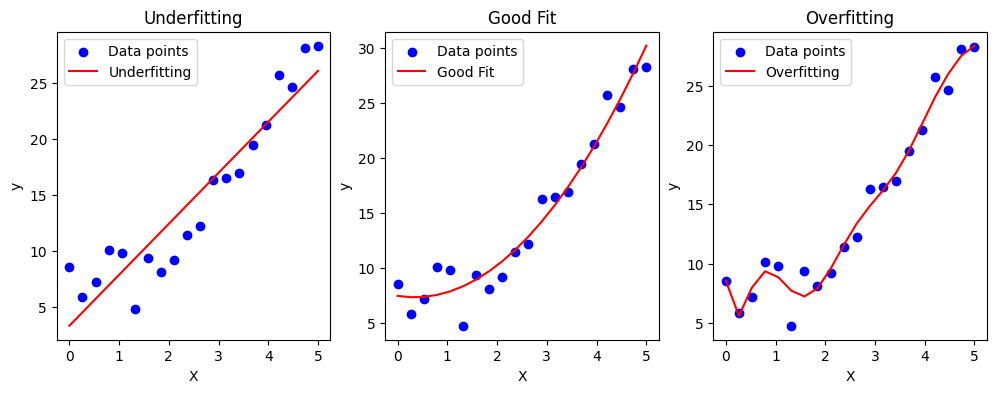

In [28]:
#fitting all three models.
plt.figure(figsize = (12,4))

#underfitting plot
plt.subplot(1,3,1)
plt.scatter(X,y,color = 'blue', label = 'Data points')
plt.plot(X,y_pred_lin,color = 'red', label = 'Underfitting')
plt.title('Underfitting')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

#good fit plot
plt.subplot(1,3,2)
plt.scatter(X,y,color = 'blue', label = 'Data points')
plt.plot(X,y_pred_poly,color = 'red', label = 'Good Fit')
plt.title('Good Fit')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

#overfitting plot
plt.subplot(1,3,3)
plt.scatter(X,y,color = 'blue', label = 'Data points')
plt.plot(X,y_pred_poly10,color = 'red', label = 'Overfitting')
plt.title('Overfitting')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

